# Comprensión y Análisis Exploratorio de Datos (EDA)
**Proyecto:** Modelo de riesgo crediticio — PIM5 Data Science

Estructura de este notebook:
1. Exploración inicial de datos
2. Análisis univariable
3. Análisis bivariable
4. Análisis multivariable
5. Hallazgos y siguientes pasos (para `ft_engineering.py`)

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

with open('config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

TARGET = config['target_column']
df = pd.read_parquet('../data_checkpoint.parquet')
print(df.shape)
df.head()

(10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## 1. Exploración inicial de datos

Tipos de variable, resumen estadístico y calidad de datos general.

In [2]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)

print(f"Variables numéricas ({len(num_cols)}): {num_cols}")
print(f"\nVariables categóricas ({len(cat_cols)}): {cat_cols}")

Variables numéricas (19): ['tipo_credito', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

Variables categóricas (3): ['fecha_prestamo', 'tipo_laboral', 'tendencia_ingresos']


C:\Users\andre\AppData\Local\Temp\ipykernel_29088\3126921594.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [3]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763.0,5.411131e+00,2.338279e+00,4.00000,4.000000e+00,4.000000e+00,9.000000e+00,6.800000e+01
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.00000,1.224831e+06,1.921920e+06,3.084840e+06,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.00000,6.000000e+00,1.000000e+01,1.200000e+01,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.00000,3.300000e+01,4.200000e+01,5.300000e+01,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.00000,2.000000e+06,3.000000e+06,4.875808e+06,2.200000e+10
total_otros_prestamos,10763.0,6.238870e+06,1.184183e+08,0.00000,5.000000e+05,1.000000e+06,2.000000e+06,6.787675e+09
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.00000,1.210415e+05,1.828630e+05,2.878335e+05,3.816752e+06
puntaje,10763.0,9.117004e+01,1.646544e+01,-38.00999,9.522779e+01,9.522779e+01,9.522779e+01,9.522779e+01
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.00000,7.570000e+02,7.910000e+02,8.250000e+02,9.990000e+02
cant_creditosvigentes,10763.0,5.726749e+00,3.977162e+00,0.00000,3.000000e+00,5.000000e+00,8.000000e+00,6.200000e+01


In [4]:
# Calidad de datos: nulos por columna
nulls = (df.isna().sum() / len(df) * 100).round(2)
nulls = nulls[nulls > 0].sort_values(ascending=False)
nulls.to_frame('% nulos')

,% nulos
tendencia_ingresos,27.24
promedio_ingresos_datacredito,27.22
saldo_mora_codeudor,5.48
saldo_principal,3.76
saldo_mora,1.45
saldo_total,1.45
puntaje_datacredito,0.06


**Hallazgo de calidad de datos:** la columna `tendencia_ingresos` debería ser categórica
(Creciente / Decreciente / Estable) pero contiene valores numéricos sueltos mezclados,
probablemente por un error de carga/desplazamiento de columnas en el sistema origen.
Esto se documenta aquí y se corrige en `ft_engineering.py`, no en este notebook.

In [5]:
df['tendencia_ingresos'].value_counts().head(10)

tendencia_ingresos
Creciente      5294
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
Name: count, dtype: int64

## 2. Análisis univariable

### 2.1 Variable objetivo: `Pago_atiempo`

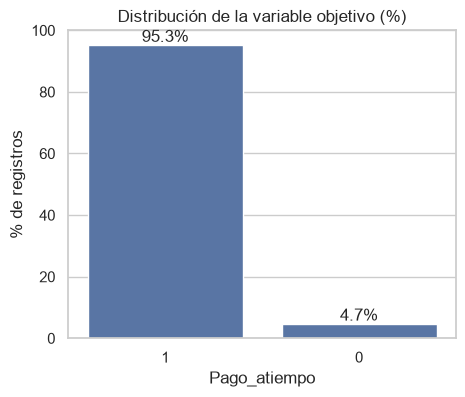

Pago_atiempo
1    95.252253
0     4.747747
Name: proportion, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(5,4))
counts = df[TARGET].value_counts(normalize=True) * 100
sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
ax.set_title('Distribución de la variable objetivo (%)')
ax.set_xlabel(TARGET)
ax.set_ylabel('% de registros')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

print(counts)

**Hallazgo:** el dataset está **fuertemente desbalanceado** (~95% pagan a tiempo vs ~5% no).
Esto es típico en riesgo crediticio, pero implica que en la etapa de modelado (Avance #2) no alcanza
con mirar accuracy: hay que usar métricas como recall, F1, ROC-AUC y considerar balanceo de clases
(class_weight, SMOTE, undersampling, etc.).

### 2.2 Variables numéricas

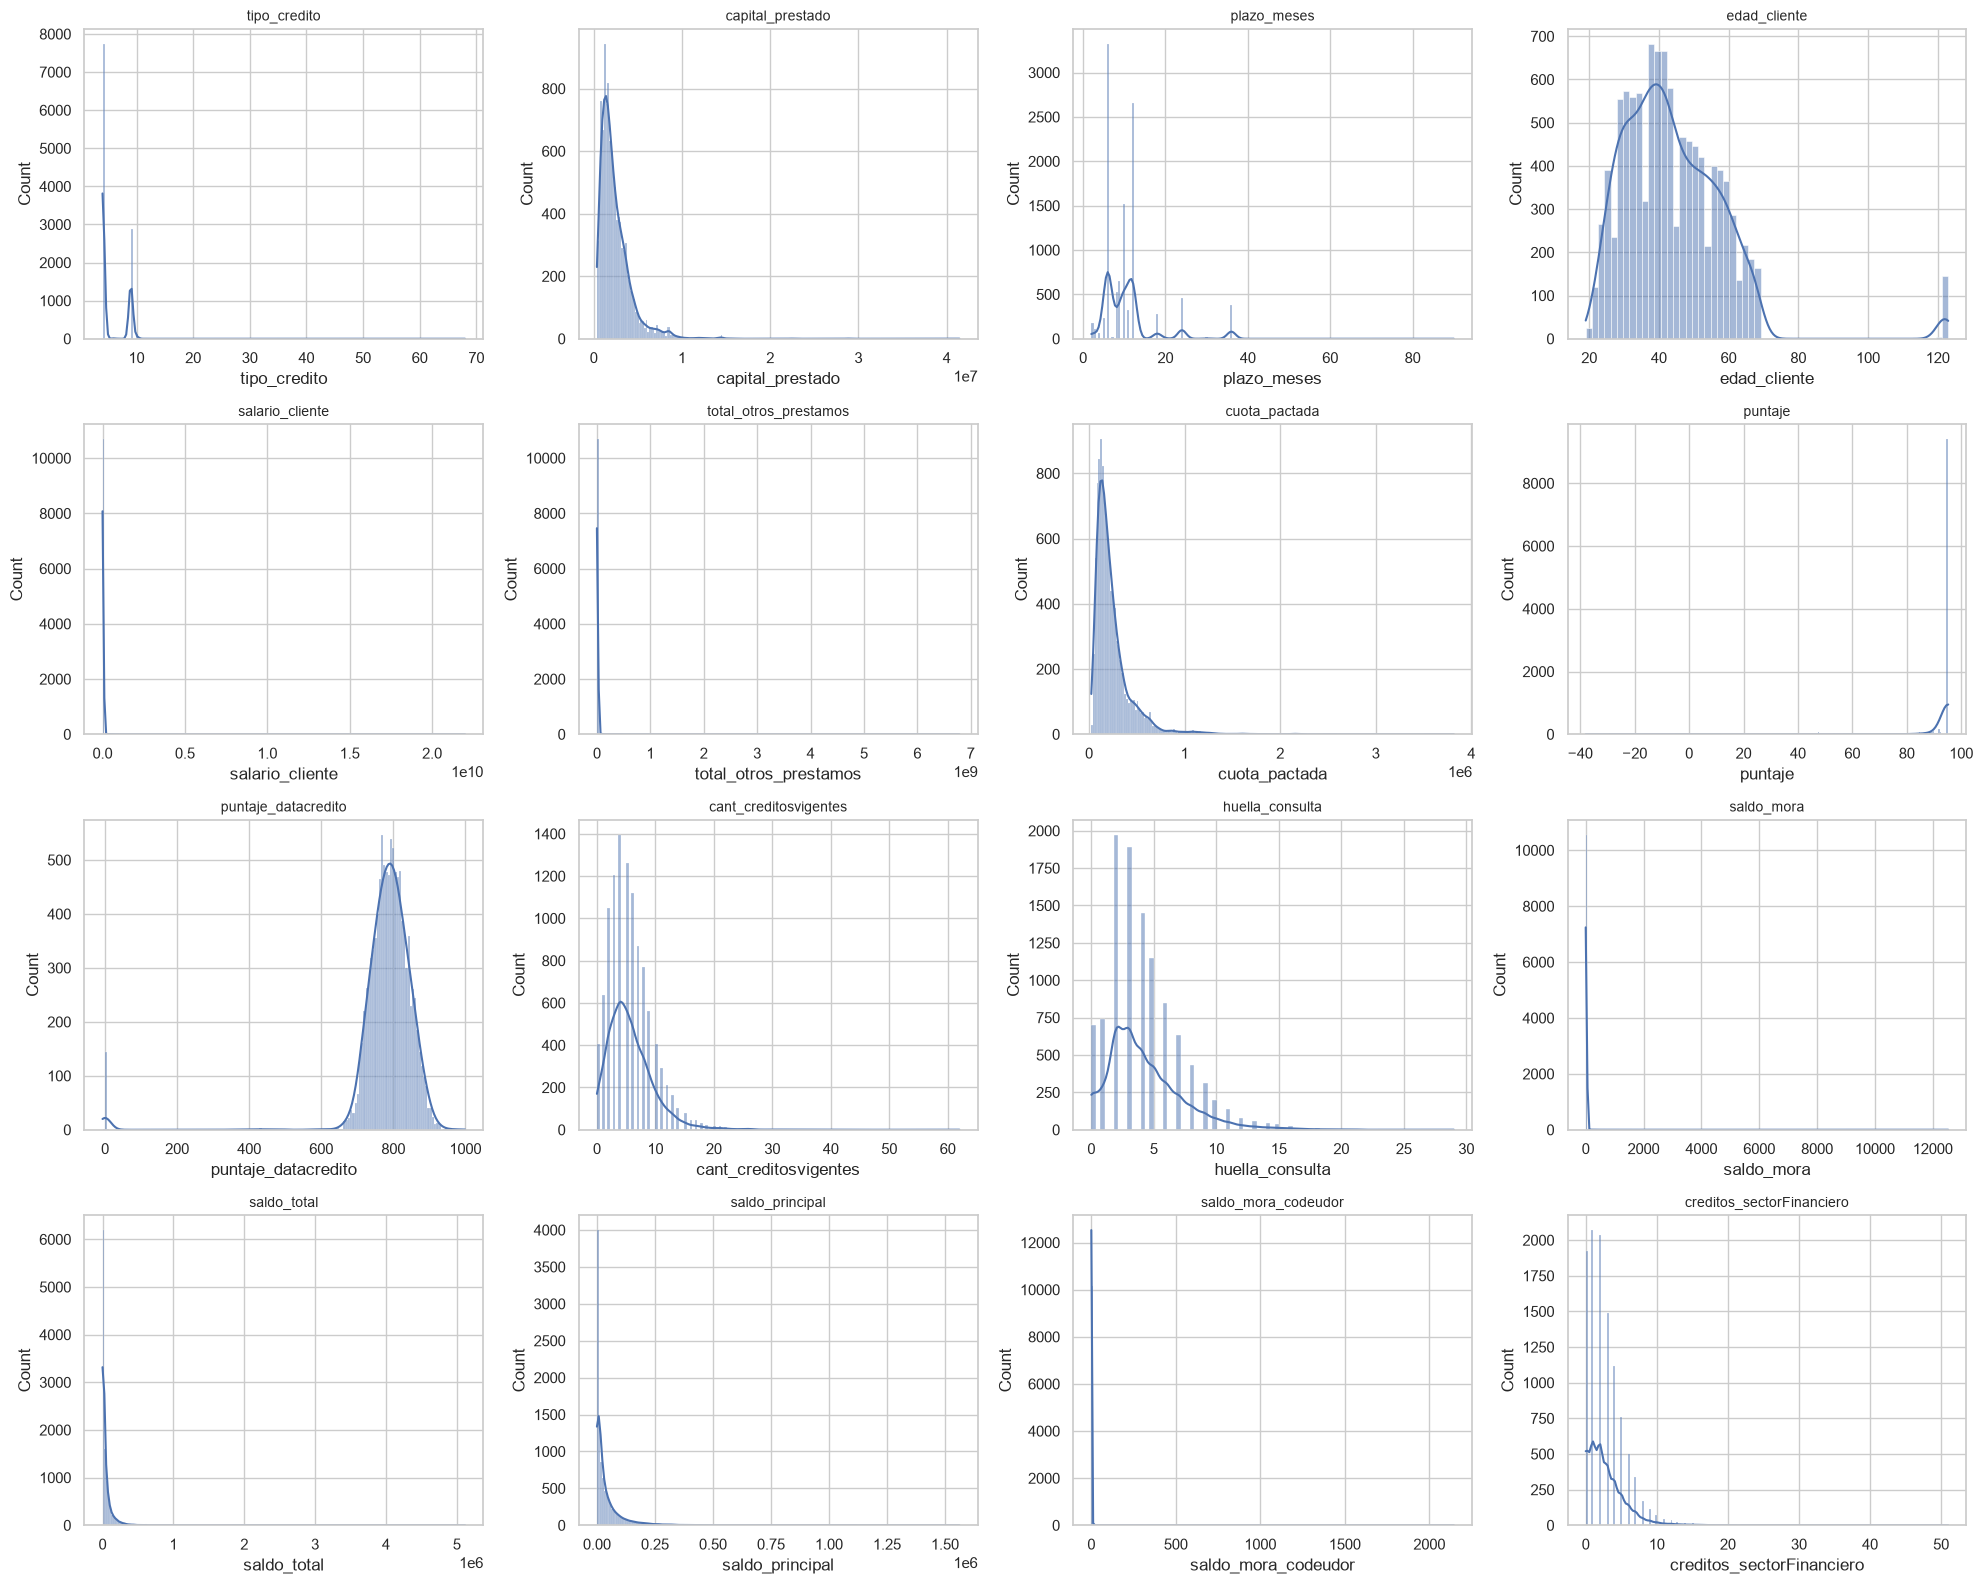

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols[:16]):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

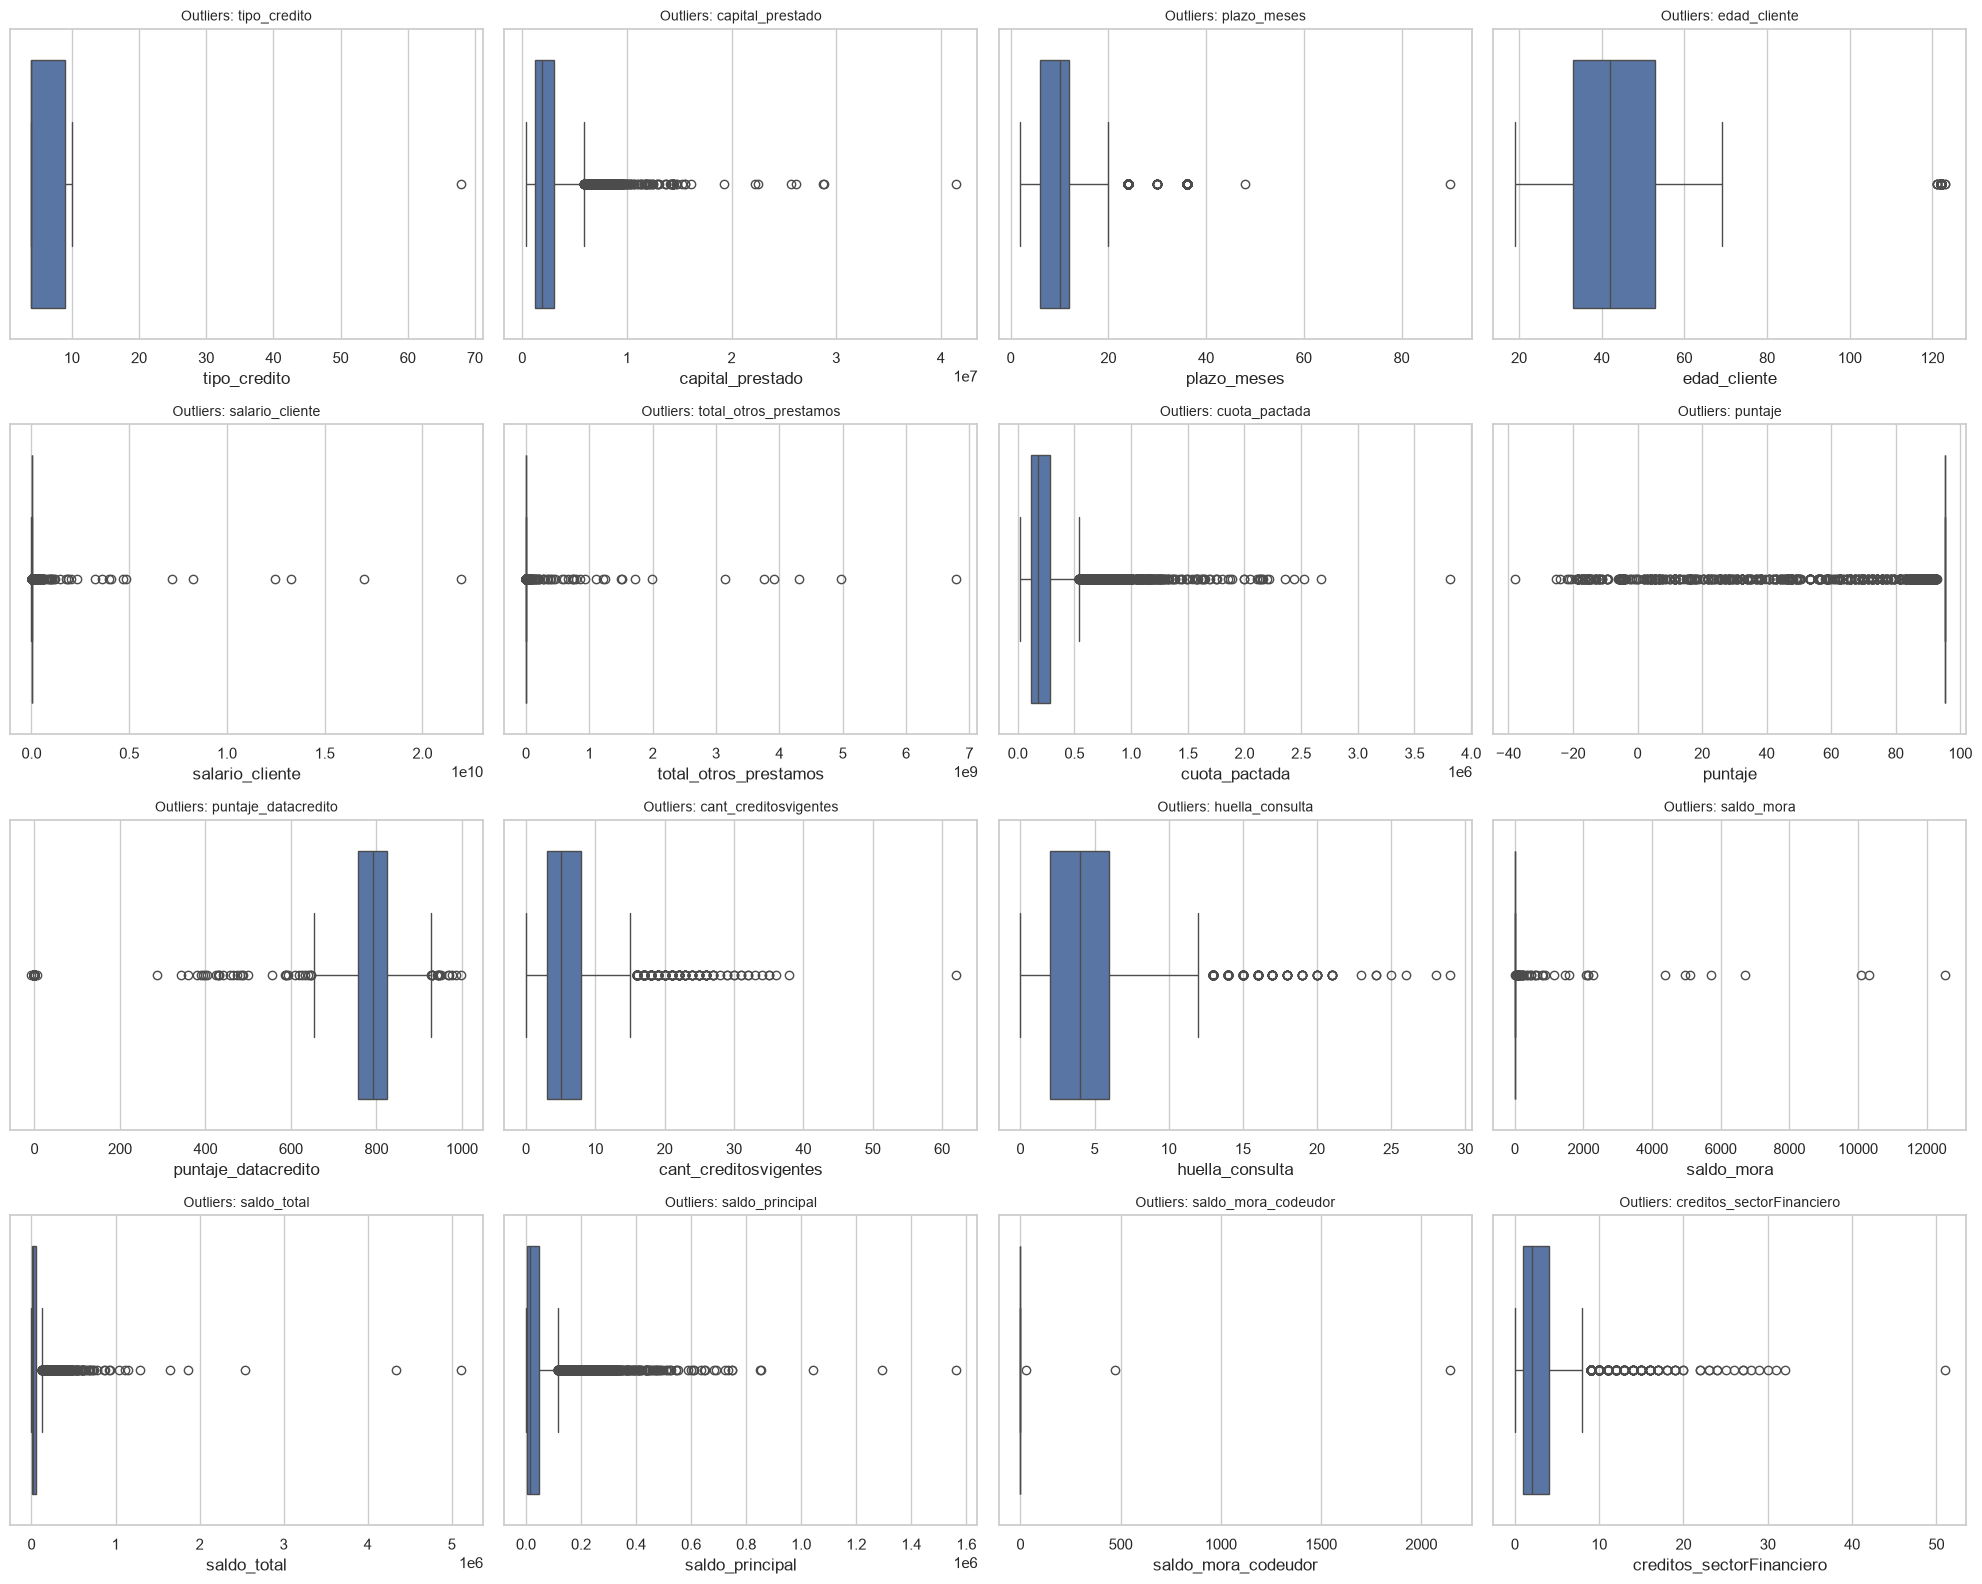

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols[:16]):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Outliers: {col}', fontsize=10)
plt.tight_layout()
plt.show()

### 2.3 Variables categóricas

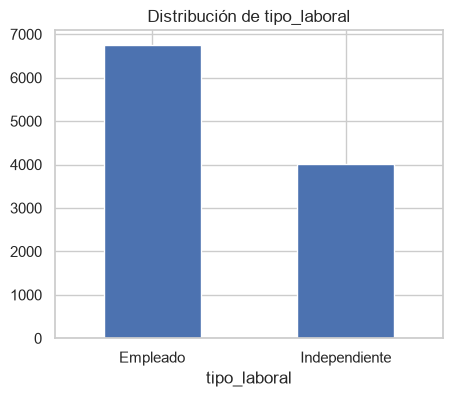

In [9]:
for col in ['tipo_laboral']:
    fig, ax = plt.subplots(figsize=(5,4))
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Distribución de {col}')
    plt.xticks(rotation=0)
    plt.show()

## 3. Análisis bivariable

Relación de cada variable con la variable objetivo `Pago_atiempo`.

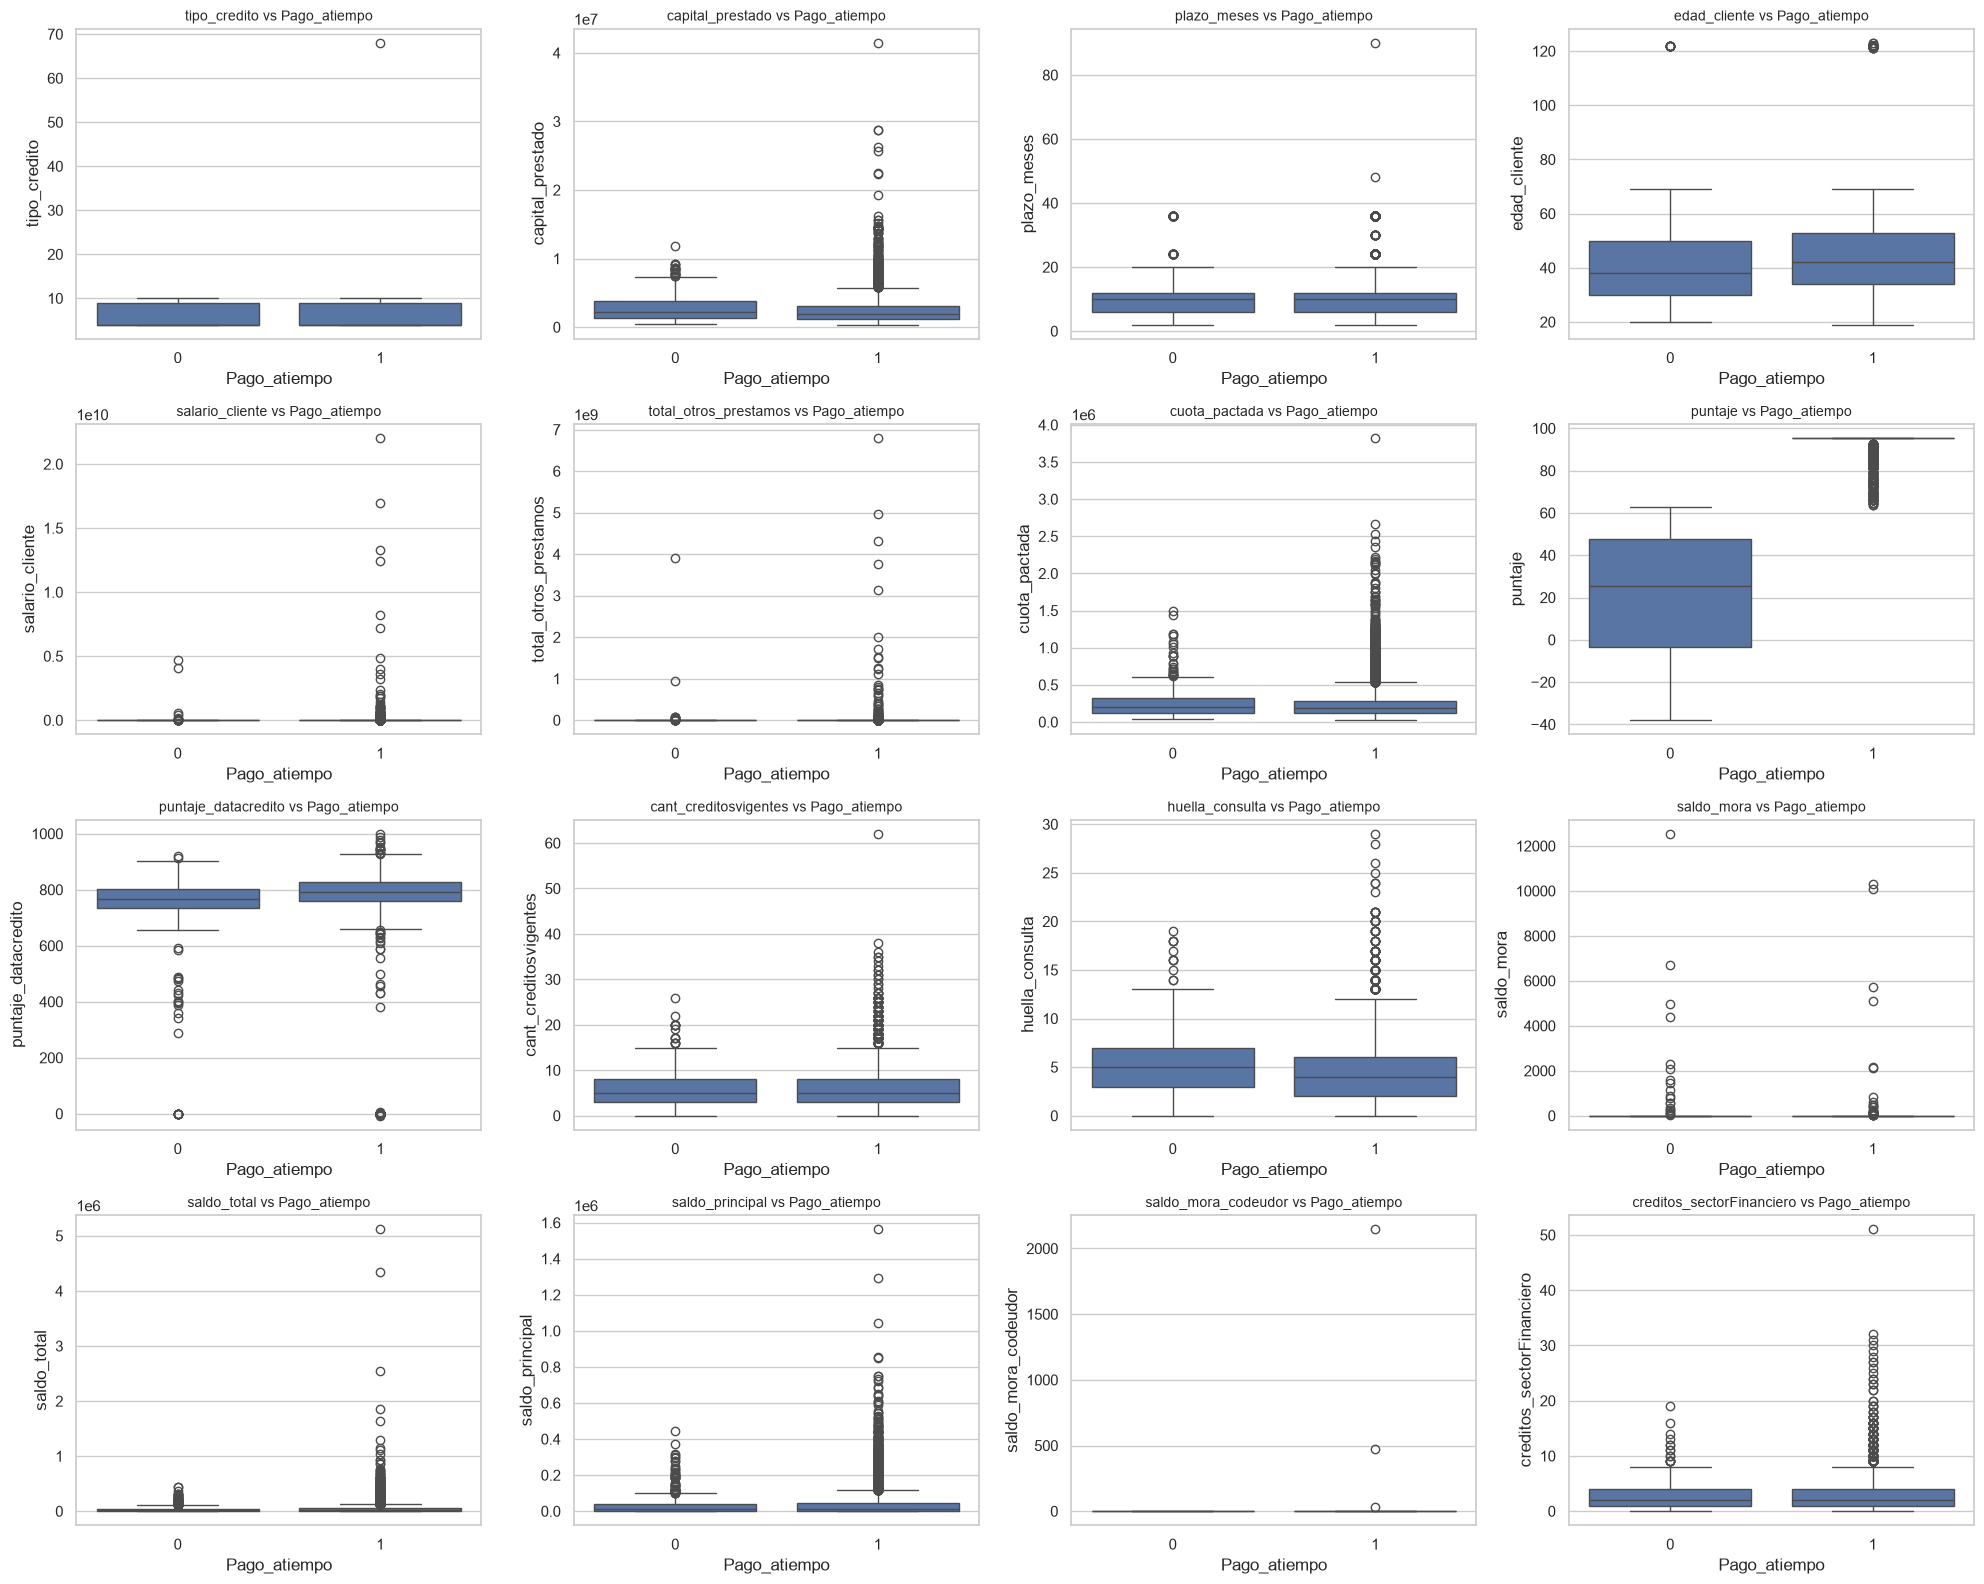

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols[:16]):
    sns.boxplot(data=df, x=TARGET, y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs {TARGET}', fontsize=10)
plt.tight_layout()
plt.show()

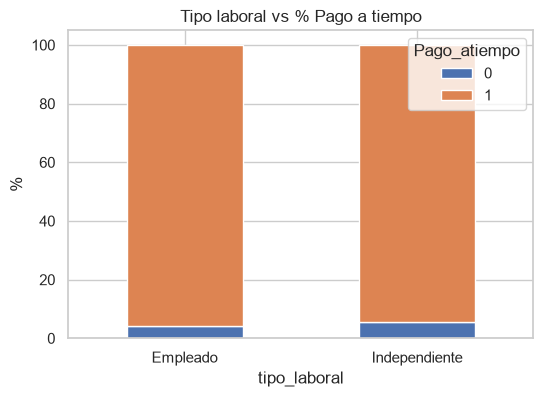

Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.293752,95.706248
Independiente,5.512597,94.487403


In [11]:
ct = pd.crosstab(df['tipo_laboral'], df[TARGET], normalize='index') * 100
ct.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title('Tipo laboral vs % Pago a tiempo')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.show()
ct

## 4. Análisis multivariable

Correlaciones entre variables numéricas y relaciones cruzadas.

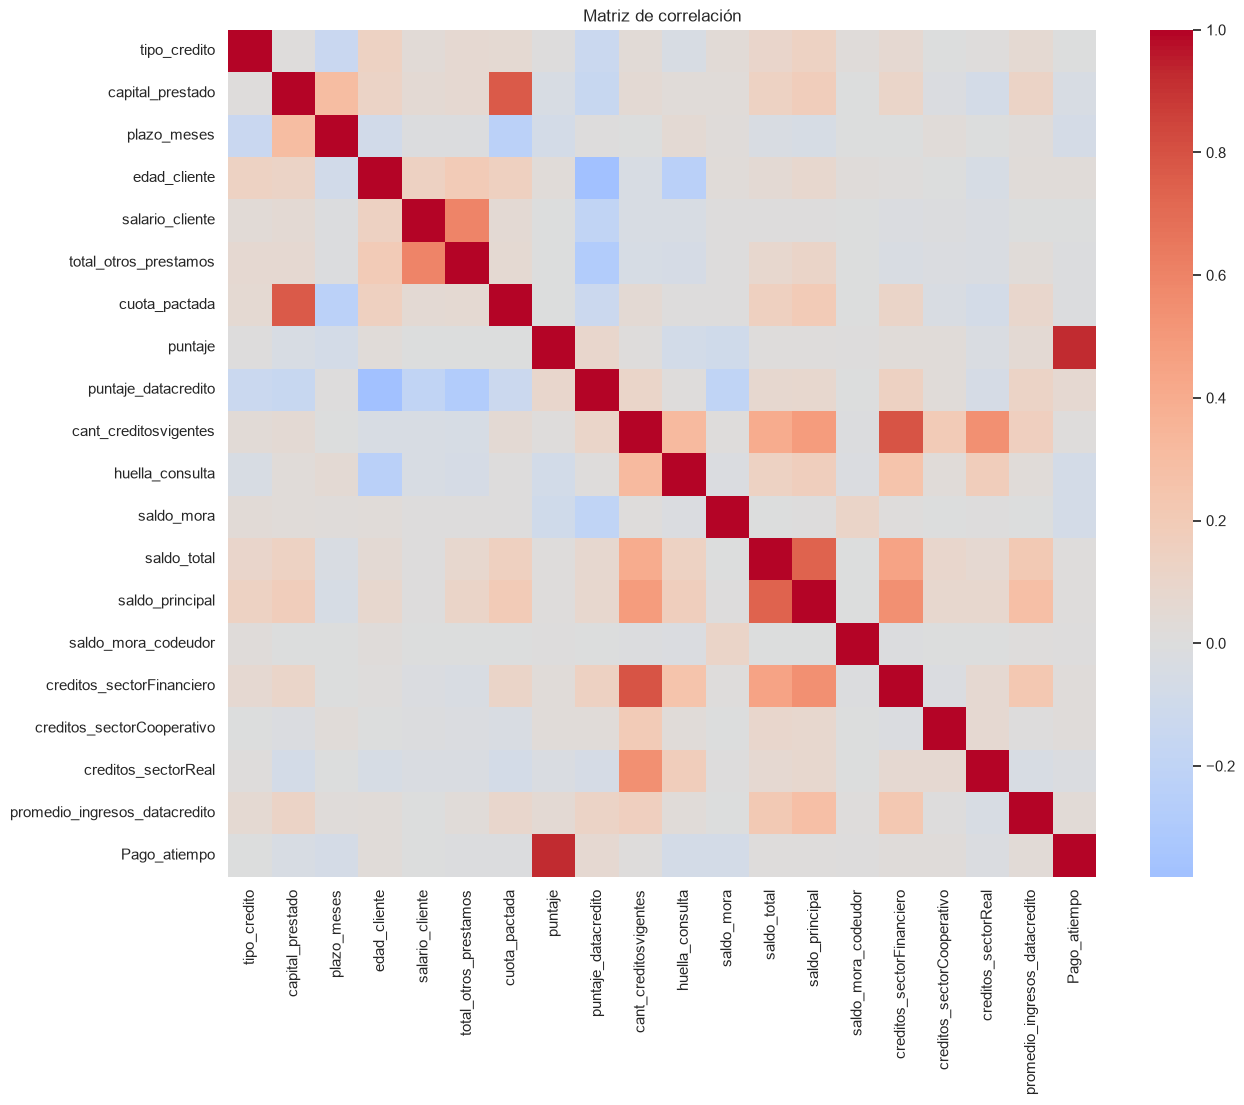

In [12]:
corr = df[num_cols + [TARGET]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de correlación')
plt.show()

In [13]:
corr_target = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
corr_target.to_frame('correlación con ' + TARGET).head(10)

,correlación con Pago_atiempo
puntaje,0.923134
huella_consulta,-0.073737
saldo_mora,-0.073458
puntaje_datacredito,0.067882
plazo_meses,-0.063105
capital_prestado,-0.040624
promedio_ingresos_datacredito,0.039867
edad_cliente,0.032252
creditos_sectorReal,-0.023306
creditos_sectorFinanciero,0.021390


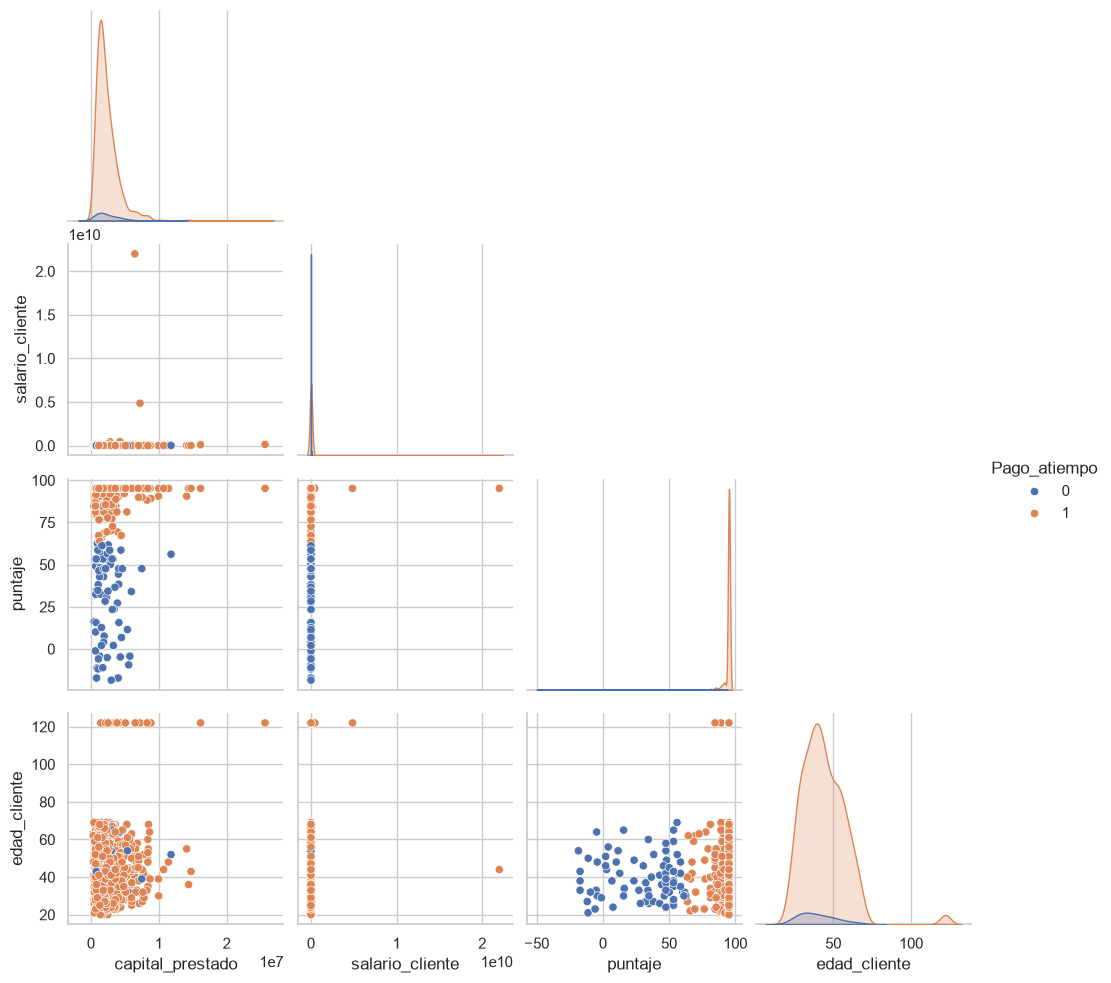

In [14]:
sns.pairplot(
    df.sample(min(1500, len(df)), random_state=42),
    vars=['capital_prestado', 'salario_cliente', 'puntaje', 'edad_cliente'],
    hue=TARGET,
    corner=True
)
plt.show()

## 5. Hallazgos y siguientes pasos

**Resumen de hallazgos:**
- Variable objetivo muy desbalanceada (~5% clase minoritaria) → considerar `class_weight` / técnicas de balanceo en el modelado.
- Nulos relevantes en `promedio_ingresos_datacredito` y `tendencia_ingresos` (~27%), y nulos menores en columnas de saldo → definir estrategia de imputación.
- `tendencia_ingresos` tiene valores sucios (numéricos en vez de categóricos) → limpiar antes de encodear.
- `puntaje_datacredito` está tipado como texto en el origen → convertir a numérico.
- Existen variables con correlación relevante con el target (ver tabla de correlaciones) → candidatas fuertes para el modelo.

**Siguientes pasos (Avance #2 — `ft_engineering.py`):**
- Limpiar `tendencia_ingresos` y convertir `puntaje_datacredito` a numérico.
- Definir estrategia de imputación para nulos.
- Encodear variables categóricas (`tipo_laboral`, `tendencia_ingresos`).
- Evaluar necesidad de balanceo de clases antes de entrenar.